In [ ]:
import torch
import numpy as np
import pandas as pd
from typing import List

from langchain_core.embeddings import Embeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.stores import InMemoryByteStore
#from langchain_community.retrievers.multi_vector import MultiVectorRetriever
from langchain_core.runnables import RunnablePassthrough

from langchain.chat_models import init_chat_model
from functools import partial
from langchain_core.output_parsers import StrOutputParser
import json
import uuid
from typing import List, Dict, Any

from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.retrievers import BaseRetriever
from langchain_core.stores import BaseStore
from langchain_core.vectorstores import VectorStore


from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document



think_prompt = {'justification':
ChatPromptTemplate.from_messages([(
    rf"""<s> [INST]
Explain how the justification for bypassing the restriction complies with regulatory documents and the specifics of the case, using only the specified context. Refer to the document path.
You are a professional lawyer working for a large Russian IT company.
Prioritize documents that directly answer the question. Provide clear and precise information in your answer, without unnecessary detail.
Consider the specifics of the case.
Your goal is to accurately answer the user's question.
The problem described in the context should match the problem in the user's question.
Favor sources that directly answer the question.


Context:
{{context}}

Document by User: 
{{text}}

Is this a violation or not?
Your answer:
[/INST]"""
),]),
'base':
ChatPromptTemplate.from_messages([(
    rf"""<s> [INST]
Explain how the document's content aligns with the regulatory documents and the specifics of the case, using only the specified context. Provide the path to the document.
You are a professional lawyer working for a large Russian IT company.
Prioritize documents that directly answer the question. Provide clear and precise information in your answer, without unnecessary detail.
Consider the specifics of the case.
Your goal is to accurately answer the user's question.
The problem described in the context should match the problem in the user's question.
Favor sources that directly answer the question.


Context:
{{context}}

Document by User: 
{{text}}

Is this a violation or not?
Your answer:
[/INST]"""
),]),
}
final_prompt = ChatPromptTemplate.from_messages([(
    rf"""[INST]
- Your primary task is to final and briefly state whether any violations were identified in the analyzed case.

- You only answer "yes" or "no," without comment. You don't need to write anything other than "yes" or "no."

Case:
{{text}}

Label: [MASK]
[/INST]"""
),])


def final_func(**kwargs):
    chain = (
        final_prompt
        | llm.with_config(configurable={'num_predict': 1})
        | StrOutputParser()
    )
    return chain
 
#в университетской, версии у мееня конечно нет ограничений на библиотеки, но на работе комьюнити для меня пока не доступен по бюрократическим, так что сделал вот такой трюк
class MultiVectorRetriever(BaseRetriever):
    vectorstore: VectorStore
    docstore: BaseStore[str, Document]
    id_key: str = "doc_id"
    search_kwargs: Dict[str, Any] = {}
    def _get_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> List[Document]:
        doc_hp = self.vectorstore.similarity_search(query, **self.search_kwargs)
        doc_ids: List[str] = []
        for doc in doc_hp:
            if self.id_key in doc.metadata:
                doc_ids.append(doc.metadata[self.id_key])
        doc_ids = list(set(doc_ids))
        docs = self.docstore.mget(doc_ids)
        return [doc for doc in docs if doc is not None]

    async def _aget_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> List[Document]:
        doc_hp = await self.vectorstore.asimilarity_search(query, **self.search_kwargs)
        doc_ids: List[str] = []
        for i in doc_hp:
            if self.id_key in i.metadata:
                doc_ids.append(i.metadata[self.id_key])

        doc_ids = list(set(doc_ids))
        docs = await self.docstore.amget(doc_ids)
        return [i for i in docs if i is not None]

#для домашнего тестирования
llm = init_chat_model(
    model="qwen/qwen3-4b-2507",
    model_provider="openai",
    base_url="http://127.0.0.1:1234/v1",
    api_key="lm-studio"
)

DEVICE = f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu"

#пока разбираемся что по эмбедингам нам можно. а что нет написал вот такой заполнитель, по тем же причинам по которым мне не дали просто импортировать MultiVectorRetriever
class AdvancedStatisticalEmbeddings(Embeddings):
    def __init__(self, dim: int = 1536, ngram_range: tuple = (3, 5), seed: int = 42):
        self.dim = dim
        self.ngram_range = ngram_range
        torch.manual_seed(seed)
        np.random.seed(seed)
        self.device = torch.device(DEVICE)

    def _hash(self, s: str) -> int:
        return hash(s) & 0x7FFFFFFF

    def _get_ngrams(self, text: str) -> List[str]:
        text = text.lower().strip()
        ngrams = []
        for n in range(self.ngram_range[0], self.ngram_range[1] + 1):
            for i in range(len(text) - n + 1):
                ngrams.append(text[i:i + n])
        return ngrams

    def _text_to_vector(self, text: str) -> np.ndarray:
        vec = np.zeros(self.dim, dtype=np.float32)
        
        #Word-level
        words = [w for w in text.lower().split() if len(w) > 1]
        for word in words:
            h = self._hash(word) % self.dim
            vec[h] += 1.0
        
        #Char n-grams
        ngrams = self._get_ngrams(text)
        for ng in ngrams:
            h = self._hash(ng) % self.dim
            vec[h] += 0.5
        
        #Простая TF-нормализация
        norm = np.linalg.norm(vec)
        if norm > 0:
            vec = vec / norm
        
        #torch-нормализация
        vec_tensor = torch.from_numpy(vec).to(self.device)
        vec_tensor = torch.nn.functional.normalize(vec_tensor, p=2, dim=0)
        
        return vec_tensor.cpu().numpy()

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        return [self._text_to_vector(t).tolist() for t in texts]

    def embed_query(self, text: str) -> List[float]:
        return self._text_to_vector(text).tolist()



embeddings = AdvancedStatisticalEmbeddings(dim=1536)
vectorstore = InMemoryVectorStore(embedding=embeddings)
store = InMemoryByteStore()


def doc_info_func(record: dict, doc_info: dict) -> dict:
    doc_info["path"] = record.get("path")
    doc_info["section_name"] = record.get("section_name", "")
    doc_info['chapter_name'] = record.get("chapter_name", "")
    doc_info['text'] = record.get("text", "")
    return doc_info

retriever = MultiVectorRetriever(vectorstore=vectorstore, docstore=store, 
    search_kwargs={"k": 10}, 
    id_key="doc_id")


def _split_text(text: str, ln_size: int, ln_overlap: int) -> List[str]:
    parts = []
    start = 0
    text_len = len(text)
    while start < text_len:
        end = min(start + ln_size, text_len)
        parts.append(text[start:end])
        start += ln_size - ln_overlap
    return parts


def load_docs(file_path: str, ln_size: int = 1200, ln_overlap: int = 300, id_key: str = "doc_id") -> tuple[List[Document], List[Document], List[str]]:
    if file_path.endswith(".jsonl"):
        with open(file_path, "r", encoding="utf-8") as f:
            articles = [json.loads(line) for line in f if line.strip()]
    else:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            if "documents" in data:
                articles = data["documents"]
            else:
                articles = data.get("articles", [])

    parent_docs: List[Document] = []
    doc_ids: List[str] = []

    for i in articles:
        content = i.get("text") or i.get("content", "")

        metadata = doc_info_func(i, {})
        if "tags" in i:
            metadata["tags"] = i["tags"]

        parent_doc = Document(page_content=content, metadata=metadata)
        parent_docs.append(parent_doc)
        doc_id = i.get(id_key) or str(uuid.uuid4())
        parent_doc.metadata[id_key] = doc_id
        doc_ids.append(doc_id)
    doc_hp: List[Document] = []
    for parent_doc, doc_id in zip(parent_docs, doc_ids):
        chunks = _split_text(parent_doc.page_content, ln_size, ln_overlap)
        for i, chunk_text in enumerate(chunks):
            metadata_hp = parent_doc.metadata.copy()
            metadata_hp["chunk_id"] = f"{doc_id}_{i}"
            doc_hp.append(Document(page_content=chunk_text, metadata=metadata_hp))
    return parent_docs, doc_hp, doc_ids


file_paths=[
    'contract_lifecycle_stage_1_preparation.json',
    'contract_lifecycle_stage_2_approval.json',
    'contract_lifecycle_stage_3_execution.json',
    'contract_lifecycle_stage_4_closure.json',
    'contract_lifecycle_special_cases.json',
    'contract_lifecycle_hr_documents.json',
    'contract_lifecycle_risk_insurance.json',
    'contract_lifecycle_automation.json',
    'contract_lifecycle_audit.json',
    'contract_lifecycle_special_contracts.json',
    'contract_lifecycle_detailed_procedures.json',
    'contract_lifecycle_escalation_matrix.json',
    'contract_lifecycle_risk_quantification.json',
    'contract_lifecycle_compliance_audit_detailed.json',
    'contract_lifecycle_interaction_with_state.json',
    'contract_lifecycle_template_management.json',
    'contract_lifecycle_termination.json',
    'contract_lifecycle_claims_litigation.json',
    'contract_lifecycle_archiving_erp.json',
    'contract_lifecycle_personal_data_special_cases.json',
]
import glob
for i in glob.glob('storage/*.json'):#file_paths:
    docs, doc_hp, doc_ids = load_docs(i, 1200, 300, "doc_id")

    retriever.vectorstore.add_documents(doc_hp)
    retriever.docstore.mset(list(zip(doc_ids, docs)))


def merge_contexts(results: list[list]) -> str:
    context = []
    for result in results:
        context += [
            f"\Документ {result[0].metadata['path']} "
            f"({result[0].metadata['document']}): \n "
            f"{result[0].page_content} \n"
        ]
    return "".join(context)


def merge_contexts(docs) -> str:
    if not docs:
        return ""
    elif isinstance(docs, Document):#если вытащен один
        docs = [docs]

    context = []
    for doc in docs:
        context.append(
            f"Документ {doc.metadata.get('path', '')} "
            f"({doc.metadata.get('document', '')}):\n "
            f"{doc.page_content}\n"
        )
    return "\n".join(context)


def think_func(l=0, **kwargs):
    chain = (
        think_prompt['base']
        | llm
        | StrOutputParser()
    )
    return chain
#'''
def debu(x):
    print(x)
    return x
def preproc_cont_func(n=3,**kwargs):
    chain = (
        RunnablePassthrough()
        | retriever
        #| debu
        | (lambda x: x[:n] if len(x) > n else x)
        | merge_contexts
    )
    return chain


def process_answer(query, think_chain, preproc_cont_chain, final_func, l, k):
    
    contexts = process_contexts(query, preproc_cont_chain=preproc_cont_chain, k=k)

    result = think_chain.invoke({"context": contexts
                                  , 'text': query
                                  }, l=l)
    #print(result)
    final_answer = final_func.invoke({
                "text": result,
            })
    #print(final_answer)
    y=False
    #print(final_answer)
    final_answer=final_answer.strip().lower()[:3]
    if final_answer=='yes':
        y=True
    elif final_answer!='no':
        print('final_answer',final_answer)

    return y, (result + '\n\n' + contexts)

def process_contexts(query, preproc_cont_chain, k
                     ):
    contexts = np.array(preproc_cont_chain.invoke(
                                                     query))
    res, ind = np.unique(contexts, return_index=True)
    contexts = res[np.argsort(ind)][:k]
    #print(contexts)
    return contexts


#долить больше контекста по договору с модификациями пути - вариант по тегам
def pipline_func(l,**kwargs):
    chain = (
        RunnablePassthrough()
        | partial(
            process_answer,
            think_chain=think_func(**kwargs),
            preproc_cont_chain=preproc_cont_func(**kwargs),
            final_func=final_func(**kwargs),
            l=l,
            k=3
        )
    )
    return chain

pipline_func(l=0).invoke("Дополнительное соглашение №3 к договору аренды здания №А-456 от 01.01.2022. Контрагент - ООО ''НедвижимостьПлюс. Статус проверки и ограничений контрагента - без аванса. Согласующие: 1) Инициатор (руководитель договорного отдела) Белова О.А.: 'Дополнительное соглашение №3 к договору аренды здания №А-456 от 01.01.2022: снижение арендной платы на 25% на 6 месяцев в связи с ''ремонтом, который делает арендодатель, и мы не можем использовать помещение''. Арендодатель – ООО ''НедвижимостьПлюс'', не аффилирован. Приложено письмо арендодателя.'; 2) Юрист Анисимова Т.Р.: 'В договоре п.9.1: ''Снижение арендной платы допускается только при форс-мажоре или существенном изменении обстоятельств''. Ремонт – не форс-мажор. Инициатор утверждает, что ''ремонт делает арендодатель, это его воля, но мы не можем использовать, поэтому это существенное изменение''.'; 3) Финансовый аналитик Круглов С.В.: 'Снижение на 6 месяцев даст экономию 3 млн руб. Это выгодно. Но налоговый риск: если налоговая решит, что это нерыночная сделка (25% – слишком много), могут доначислить налог на прибыль (экономия необоснованна). Юридический департамент требует экспертизу.'; 4) Налоговый юрист (внешний): 'Риск средний. Рекомендую снизить не более чем на 15%. Инициатор согласовал с арендодателем 15%. ДС переделано. Подписано 10.04.2024.'; Подписант: Генеральный директор, подпись 10.04.2024, вступление в силу 15.04.2024.")

(False,
 array(['The action described in the user\'s query — the signing of a supplementary agreement №3 to rental agreement №А-456 — **does not constitute a violation** of the company’s internal policy or regulatory requirements, based on the provided context.\n\n**Path to the relevant document:**  \n/docs/templates/template_management_policy.pdf\n\n**Reasoning:**\n\n1. **Applicability of the template policy:**  \n   The document specifies that all types of contracts (including rental agreements) are managed through a standardized template system (TMPL-[Type]-[Version]-[Year]). The rental agreement №А-456 is governed by this policy, and the supplementary agreement is a modification of an existing contract — a scenario covered under the policy.\n\n2. **Change justification and approval process:**  \n   The request for a 25% rent reduction was challenged by the legal department, which correctly identified that "removal of rental payment due to repair by landlord" does not constitute a "

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)
import time

def evaluate_model_from_excel(excel_path, name='test ', d_type='d_type', query_col='query', label_col='true_label'):
    df = pd.read_csv(excel_path)#
    
    y_pred = []
    detailed_responses = []
    
    #print(len(df))
    print(name)
    for idx, row in df.iterrows():
        #print(row[d_type], row[query_col])
        #чуть жалею свой компьютер ценой скорости
        time.sleep(10)
        try:
            # Вызов модели
            tf, details = pipline_func(l=0).invoke(str(row[d_type]+':\n\n'+row[query_col]))
            y_pred.append(tf)
            detailed_responses.append(details)
        except Exception as e:
            print(f"except {idx} - {e}")
            y_pred.append(False)
            detailed_responses.append("ERROR")
    df['predicted_label'] = np.array(y_pred, dtype=bool)
    
    tn, fp, fn, tp = confusion_matrix(df[label_col], df['predicted_label']).ravel()
    #accuracy - нам не подходил из-за дисбаланса классов, в рабочей это перекос в пользу отсутствия нарушений, в синтетике дисбаланс не настолько значим, но последствия пропуска всё-таки перевешивают "проверку лишнего документа"
    #f1_score - в итоге решили взять за приоритетный
    print(name)
    print(f"f1: {f1_score(df[label_col], df['predicted_label'], zero_division=0):.4f}")
    
    print(f"confusion_matrix:\n TN={tn}, FP={fp}\n FN={fn}, TP={tp}")
    print(f"precision: {precision_score(df[label_col], df['predicted_label'], zero_division=0):.4f}")
    print(f"recall: {recall_score(df[label_col], df['predicted_label'], zero_division=0):.4f}")
    print(f"matthew: {matthews_corrcoef(df[label_col], df['predicted_label']):.4f}")
    print(classification_report(df[label_col], df['predicted_label'], target_names=['Нет нарушения', 'Нарушение']))
    

    df['model_response'] = detailed_responses
    df.to_csv(f"predict_{name}.csv", index=False)
    


evaluate_model_from_excel("test_queries.csv")

test 
test 
f1: 0.6763
confusion_matrix:
 TN=74, FP=38
 FN=29, TP=70
precision: 0.6481
recall: 0.7071
matthew: 0.3672
               precision    recall  f1-score   support

Нет нарушения       0.72      0.66      0.69       112
    Нарушение       0.65      0.71      0.68        99

     accuracy                           0.68       211
    macro avg       0.68      0.68      0.68       211
 weighted avg       0.69      0.68      0.68       211



Модель - Qwen3 4B 2507

test 
f1: 0.6763
confusion_matrix:
 TN=74, FP=38
 FN=29, TP=70
precision: 0.6481
recall: 0.7071
matthew: 0.3672
               precision    recall  f1-score   support

Нет нарушения       0.72      0.66      0.69       112
    Нарушение       0.65      0.71      0.68        99

     accuracy                           0.68       211
    macro avg       0.68      0.68      0.68       211
 weighted avg       0.69      0.68      0.68       211



Примерно в трети случаев возводим напраслину на договор и с такой же вероятностью упускаем нарушение (на рабочих данные похуже, так как в случае с синтетикой было сложнее не оставлять ему подсказок), что обещает нам большое количество документов которые потребуется перепроверить ручным методом. 
С другой стороны, тактически выгоднее сперва повысить точность выявления нарушений (Recall), возможно компенсируя это тем что мы запускаем модель не на всем объеме документов, а на уже попавших в зону подозрения, чтобы сократить их число. Таким образом это уже база под потенциальное применение, а потом при доработке и повышении  (Precision) уже можно будет расширить его действие.

Ближайшие цели - анализ промежуточных результатов для ошибок.
Поиграть с переформулировками запроса для облегчения задачи РАГ и возможно пост или пред обработкой контекста.
Поиграть с вытягиванием по тегу и (работой над формой ввода)

Модель:
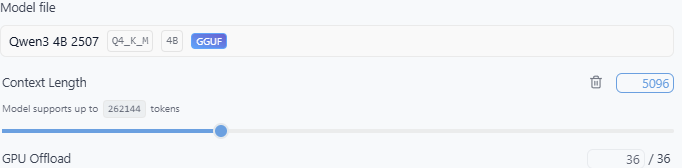